In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_traffic = pd.read_csv('/content/top-traffic-sources-30-days.csv')
print(f"\nFile 1 loaded: {df_traffic.shape[0]} rows, {df_traffic.shape[1]} columns")
print(f"Columns: {df_traffic.columns.tolist()}")
print(df_traffic.head(3))

df_active = pd.read_csv('/content/top-pages-by-active-user-7-days.csv')
print(f"\nFile 2 loaded: {df_active.shape[0]} rows, {df_active.shape[1]} columns")
print(f"Columns: {df_active.columns.tolist()}")
print(df_active.head(3))

df_pages = pd.read_csv('/content/top-10000-pages-and-screens-30-days.csv')
print(df_pages.columns.tolist())
print(df_pages.head(3))




File 1 loaded: 20 rows, 3 columns
Columns: ['session_default_channel_group', 'session_source_medium', 'visits']
  session_default_channel_group session_source_medium     visits
0                        Direct     (direct) / (none)  979305577
1                Organic Search      google / organic  542037554
2                Organic Search        bing / organic   50202528

File 2 loaded: 10000 rows, 3 columns
Columns: ['pagePath', 'Active Users', 'domain']
                       pagePath  Active Users            domain
0        /go/trackconfirmaction      10217081    tools.usps.com
1  /go/trackconfirmaction_input       9524035    tools.usps.com
2                             /       6225078  secure.login.gov
['page_title', 'domain', 'pagePath', 'pageviews']
                      page_title                 domain        pagePath  \
0              IdentityTheft.gov  www.identitytheft.gov               /   
1  National Do Not Call Registry      www.donotcall.gov               /   
2  Nationa

In [ ]:
df_traffic = pd.read_csv('/content/top-traffic-sources-30-days.csv')
df_traffic.columns = ['channel', 'source_medium', 'visits']
print(f"File 1: {df_traffic.shape[0]} rows loaded ✓")

# File 2 — Top pages by active users (10,000 rows)
df_active = pd.read_csv('/content/top-pages-by-active-user-7-days.csv')
df_active.columns = ['page_path', 'active_users', 'domain']
print(f"File 2: {df_active.shape[0]} rows loaded ✓")

# File 3 — Top 10,000 pages with page titles and pageviews
df_pages = pd.read_csv('/content/top-10000-pages-and-screens-30-days.csv')
df_pages.columns = ['page_path', 'page_title', 'domain', 'pageviews']
print(f"File 3: {df_pages.shape[0]} rows loaded ✓")

File 1: 20 rows loaded ✓
File 2: 10000 rows loaded ✓
File 3: 10000 rows loaded ✓


In [ ]:
df_traffic['visits'] = pd.to_numeric(df_traffic['visits'], errors='coerce')
df_traffic = df_traffic.dropna(subset=['channel', 'visits'])
df_traffic = df_traffic[df_traffic['visits'] > 0].drop_duplicates()
df_traffic['channel'] = df_traffic['channel'].str.strip()

# Clean active pages
df_active['active_users'] = pd.to_numeric(df_active['active_users'], errors='coerce')
df_active = df_active.dropna(subset=['page_path', 'active_users'])
df_active = df_active[df_active['active_users'] > 0]
df_active = df_active.drop_duplicates(subset=['page_path'])
df_active = df_active.sort_values('active_users', ascending=False).reset_index(drop=True)

# Clean pages
df_pages['pageviews'] = pd.to_numeric(df_pages['pageviews'], errors='coerce')
df_pages = df_pages.dropna(subset=['page_path', 'pageviews'])
df_pages = df_pages[df_pages['pageviews'] > 0]
df_pages = df_pages[df_pages['page_path'] != '(other)']
df_pages = df_pages.drop_duplicates(subset=['page_path'])
df_pages = df_pages.sort_values('pageviews', ascending=False).reset_index(drop=True)

# Merge active + pages
df_merged = pd.merge(
    df_active[['page_path', 'active_users', 'domain']],
    df_pages[['page_path', 'page_title', 'pageviews']],
    on='page_path', how='left'
)
print("All files cleaned ✓")


All files cleaned ✓


In [ ]:
total_visits = df_traffic['visits'].sum()

In [ ]:
df_traffic['visit_share_pct'] = (df_traffic['visits'] / total_visits * 100).round(2)

In [ ]:
def classify_channel(ch):
    ch = str(ch).lower()
    if any(x in ch for x in ['paid', 'cpc', 'ppc', 'ads', 'sem']):
        return 'Paid'
    elif 'organic' in ch:
        return 'Organic'
    elif 'email' in ch:
        return 'Email'
    elif 'social' in ch:
        return 'Social'
    elif 'direct' in ch:
        return 'Direct'
    elif 'referral' in ch:
        return 'Referral'
    else:
        return 'Other/Untracked'

In [ ]:
df_traffic['channel_type'] = df_traffic['channel'].apply(classify_channel)

In [ ]:
df_traffic['is_untracked'] = df_traffic['channel'].str.lower().str.contains(
    'unassigned|not set|unknown|\(other\)', na=False)

In [ ]:
df_merged['rank'] = range(1, len(df_merged) + 1)
df_merged['rank'] = range(1, len(df_merged) + 1)
df_merged['cumulative_pct'] = (
    df_merged['active_users'].cumsum() /
    df_merged['active_users'].sum() * 100).round(2)
df_merged['pages_per_user'] = (df_merged['pageviews'] / df_merged['active_users']).round(2)
df_merged['page_short'] = df_merged['page_path'].apply(
    lambda x: str(x)[:38] + '...' if len(str(x)) > 38 else str(x))

In [ ]:
type_summary  = df_traffic.groupby('channel_type')['visits'].sum().sort_values(ascending=False)
domain_agg    = df_merged.groupby('domain')['active_users'].sum().sort_values(ascending=False).head(8)
pages_for_80  = (df_merged['cumulative_pct'] <= 80).sum()
total_pages   = len(df_merged)

print("Features created ✓")

Features created ✓


# Analysis

In [ ]:
def fmt(x):
    if x >= 1e9: return f"{x/1e9:.2f}B"
    if x >= 1e6: return f"{x/1e6:.1f}M"
    if x >= 1e3: return f"{x/1e3:.0f}K"
    return str(int(x))

# Analysis 1: Traffic by channel
print("\nTRAFFIC BY CHANNEL (30 days):")
print(f"  {'Channel':<30} {'Visits':>10}  {'Share':>7}")
print("  " + "-" * 52)
for _, row in df_traffic.sort_values('visits', ascending=False).iterrows():
    print(f"  {row['channel']:<30} {fmt(row['visits']):>10}  {row['visit_share_pct']:>6.1f}%")
print(f"\n  TOTAL: {fmt(total_visits)}")

# Analysis 2: Paid vs Organic
type_summary = df_traffic.groupby('channel_type')['visits'].sum().sort_values(ascending=False)
print("\nTRAFFIC BY TYPE:")
for t, v in type_summary.items():
    print(f"  {t:<22} {fmt(v):>10}  ({v/total_visits*100:.1f}%)")


TRAFFIC BY CHANNEL (30 days):
  Channel                            Visits    Share
  ----------------------------------------------------
  Direct                             979.3M    56.3%
  Organic Search                     542.0M    31.2%
  Organic Search                      50.2M     2.9%
  Email                               25.5M     1.5%
  Unassigned                          25.4M     1.5%
  Email                               17.3M     1.0%
  Referral                            14.5M     0.8%
  Referral                            12.7M     0.7%
  Organic Search                      12.1M     0.7%
  Organic Shopping                     9.5M     0.6%
  Organic Search                       8.1M     0.5%
  Organic Shopping                     6.8M     0.4%
  Referral                             6.0M     0.3%
  Unassigned                           5.2M     0.3%
  Organic Search                       5.1M     0.3%
  Organic Search                       4.6M     0.3%
  Referral   

In [ ]:
#Analysis 3: Top 10 pages
print("\nTOP 10 PAGES (active users, 7 days):")
print(f"  {'Rank':<5} {'Domain':<28} {'Active Users':>14} {'Pageviews':>12}")
print("  " + "-" * 63)
for _, row in df_merged.head(10).iterrows():
    pv = fmt(row['pageviews']) if pd.notna(row['pageviews']) else 'N/A'
    print(f"  {row['rank']:<5} {str(row['domain']):<28} {fmt(row['active_users']):>14} {pv:>12}")

# Analysis 4: Pareto
pages_for_80 = (df_merged['cumulative_pct'] <= 80).sum()
total_pages  = len(df_merged)
print(f"\nPARETO FINDING:")
print(f"  Top {pages_for_80} pages = 80% of all active user traffic")
print(f"  ({pages_for_80/total_pages*100:.1f}% of pages drive 80% of visits)")

# Analysis 5: Most engaging pages (highest pages per user)
print("\nMOST ENGAGING PAGES (pageviews per user):")
engaged = df_merged[df_merged['pages_per_user'].notna()].nlargest(5, 'pages_per_user')
for _, row in engaged.iterrows():
    print(f"  {str(row['domain']):<30} pages/user: {row['pages_per_user']:.1f}")

# Analysis 6: Top domains by active users
print("\nTOP DOMAINS:")
domain_agg = df_merged.groupby('domain')['active_users'].sum().sort_values(ascending=False).head(8)
for d, v in domain_agg.items():
    print(f"  {str(d):<35} {fmt(v)}")


TOP 10 PAGES (active users, 7 days):
  Rank  Domain                         Active Users    Pageviews
  ---------------------------------------------------------------
  1     tools.usps.com                        10.2M          N/A
  2     tools.usps.com                         9.5M          N/A
  3     secure.login.gov                       6.2M          N/A
  4     ncbi.nlm.nih.gov                       5.5M          N/A
  5     war.gov                                4.7M          N/A
  6     ncbi.nlm.nih.gov                       4.3M          N/A
  7     informeddelivery.usps.com              3.2M          N/A
  8     secure.ssa.gov                         3.1M          N/A
  9     forecast.weather.gov                   2.9M          N/A
  10    acquisition.gov                        2.9M          N/A

PARETO FINDING:
  Top 1321 pages = 80% of all active user traffic
  (14.8% of pages drive 80% of visits)

MOST ENGAGING PAGES (pageviews per user):

TOP DOMAINS:
  tools.usps.com  

Data Quality Audit

In [ ]:
untracked_visits = df_traffic[df_traffic['is_untracked']]['visits'].sum()

checks = [
    ("QA-001", "Missing channel names",
        df_traffic['channel'].isnull().sum()),
    ("QA-002", "Missing visit counts",
        df_traffic['visits'].isnull().sum()),
    ("QA-003", "Untracked/unassigned traffic rows",
        int(df_traffic['is_untracked'].sum())),
    ("QA-004", "(not set) in source/medium",
        df_traffic['source_medium'].str.contains('not set', na=False).sum()),
    ("QA-005", "Duplicate rows — traffic file",
        df_traffic.duplicated().sum()),
    ("QA-006", "Missing page paths — pages file",
        df_active['page_path'].isnull().sum()),
    ("QA-007", "Missing active user counts",
        df_active['active_users'].isnull().sum()),
    ("QA-008", "Missing page titles — pages file",
        df_pages['page_title'].isnull().sum()),
]


In [ ]:
audit_rows = []
for qid, name, issues in checks:
    status = "PASS" if issues == 0 else "FAIL"
    audit_rows.append({'Check_ID': qid, 'Check': name,
                       'Issues': int(issues), 'Status': status})

audit_df      = pd.DataFrame(audit_rows)
passes        = (audit_df['Status'] == 'PASS').sum()
fails         = (audit_df['Status'] == 'FAIL').sum()
score         = round(passes / len(audit_df) * 100, 1)
untracked_pct = untracked_visits / total_visits * 100

print(f"QA Score: {score}% ({passes} PASS / {fails} FAIL) ✓")

QA Score: 62.5% (5 PASS / 3 FAIL) ✓


Charts and Dashboard

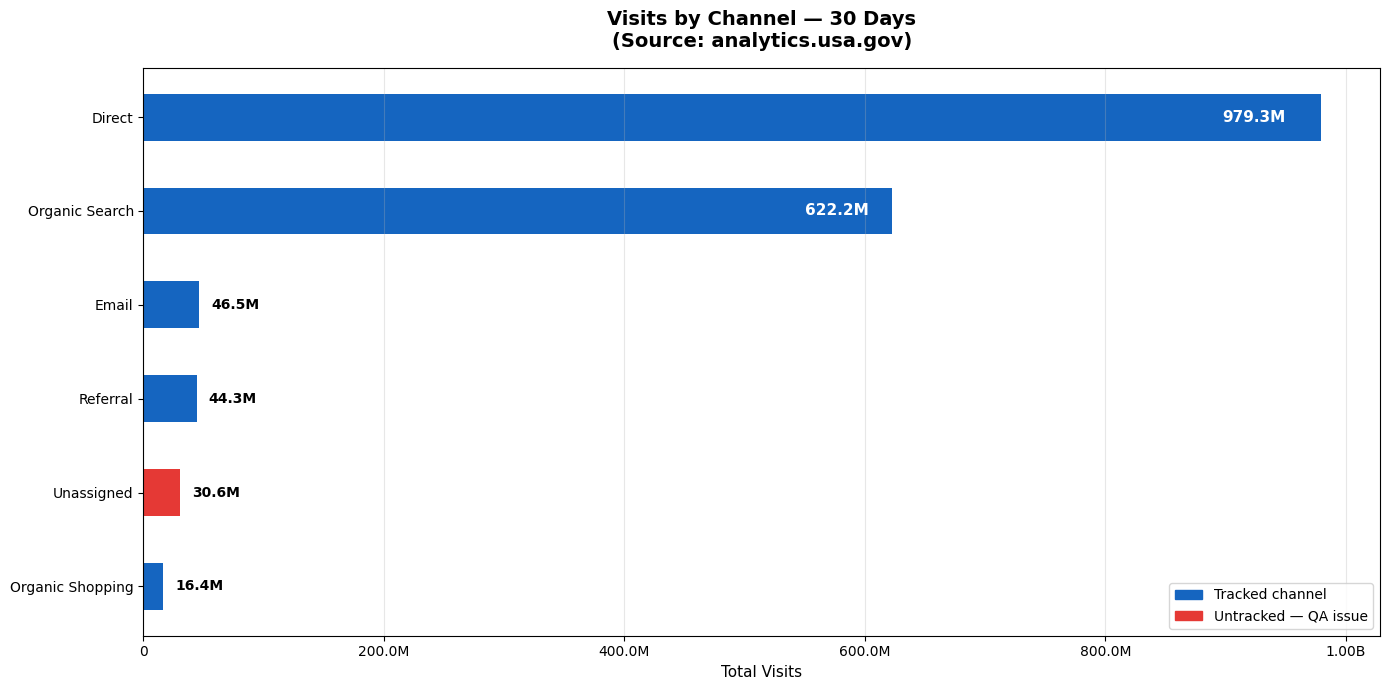

Chart 1 fixed and saved ✓


In [ ]:
#CHART 1 — Visits by Channel (Horizontal Bar)
fig1, ax1 = plt.subplots(figsize=(14, 7))


ch = df_traffic.groupby('channel', as_index=False).agg(
    visits       = ('visits', 'sum'),        # add all visits together
    is_untracked = ('is_untracked', 'max')   # keep untracked flag
)

# Sort so biggest bar is at top
ch = ch.sort_values('visits', ascending=True)

bar_col = ['#E53935' if u else '#1565C0' for u in ch['is_untracked']]
bars1   = ax1.barh(ch['channel'], ch['visits'], color=bar_col, height=0.5)

ax1.set_title('Visits by Channel — 30 Days\n(Source: analytics.usa.gov)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Total Visits', fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
ax1.grid(axis='x', alpha=0.3)

# Smart labels — inside big bars, outside small bars
max_val = ch['visits'].max()
for bar in bars1:
    w = bar.get_width()
    if w > max_val * 0.15:
        # large bar — label goes INSIDE in white
        ax1.text(w * 0.97, bar.get_y() + bar.get_height()/2,
                 fmt(w), va='center', ha='right',
                 fontsize=11, fontweight='bold', color='white')
    else:
        # small bar — label goes OUTSIDE in black
        ax1.text(w + max_val * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 fmt(w), va='center', ha='left',
                 fontsize=10, fontweight='bold', color='black')

ax1.legend(handles=[
    mpatches.Patch(color='#1565C0', label='Tracked channel'),
    mpatches.Patch(color='#E53935', label='Untracked — QA issue')
], fontsize=10)

plt.tight_layout()
plt.savefig('chart1_visits_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 fixed and saved ✓")
plt.close()


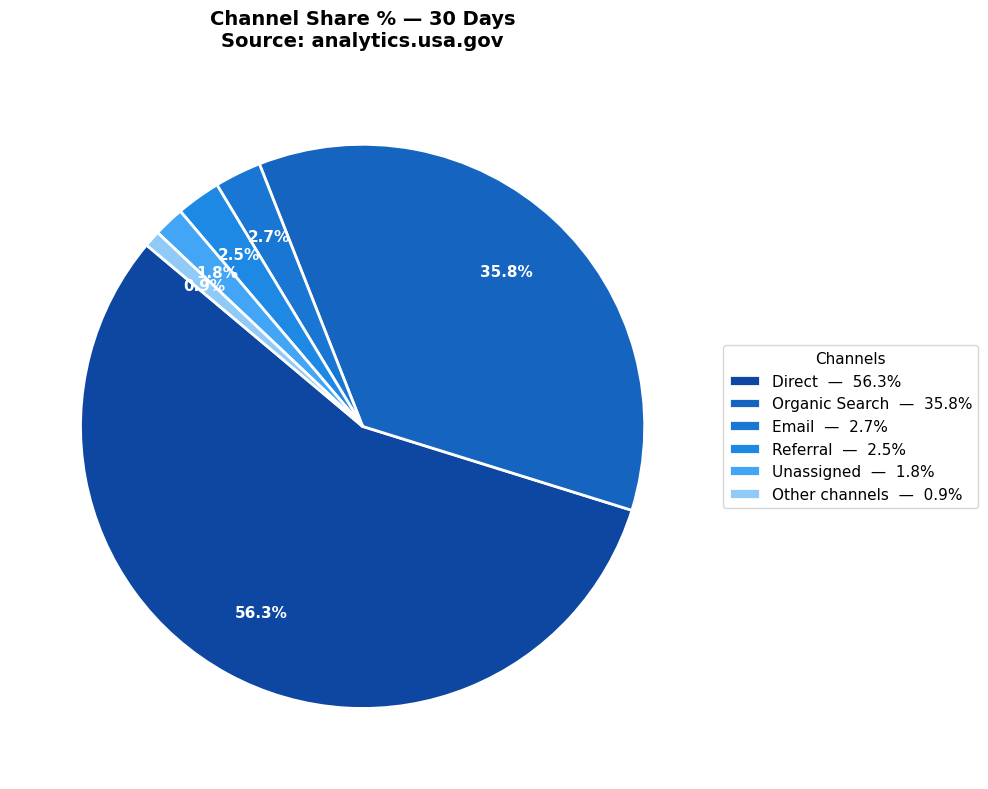

Chart 2 fixed and saved ✓


In [ ]:
# CHART 2 — Channel Share Pie Chart
fig2, ax2 = plt.subplots(figsize=(12, 8))

ch_merged = df_traffic.groupby('channel', as_index=False)['visits'].sum()
ch_merged = ch_merged.sort_values('visits', ascending=False)

top5      = ch_merged.head(5)
other_sum = ch_merged.iloc[5:]['visits'].sum()

pie_vals = list(top5['visits']) + [other_sum]
pie_lbls = list(top5['channel']) + ['Other channels']

colors_p = ['#0D47A1','#1565C0','#1976D2','#1E88E5','#42A5F5','#90CAF9']

wedges, texts, autos = ax2.pie(
    pie_vals,
    labels=None,          # NO labels on pie itself
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_p,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

# Make % labels bold and visible
for a in autos:
    a.set_fontsize(11)
    a.set_fontweight('bold')
    a.set_color('white')

# Add legend on the RIGHT side — clean and readable
ax2.legend(
    wedges,
    [f"{l}  —  {v/sum(pie_vals)*100:.1f}%"
     for l, v in zip(pie_lbls, pie_vals)],
    title="Channels",
    title_fontsize=11,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

ax2.set_title('Channel Share % — 30 Days\nSource: analytics.usa.gov',
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart2_channel_share_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 fixed and saved ✓")
plt.close()




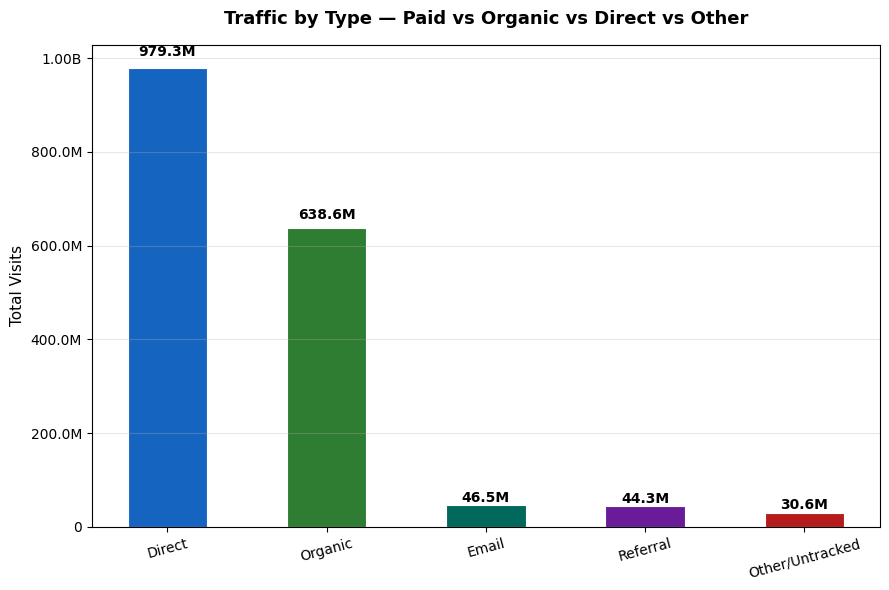

chart3_traffic_by_type.png saved ✓


In [ ]:
# CHART 3 — Traffic by Type (Paid / Organic / Direct etc.)
fig3, ax3 = plt.subplots(figsize=(9, 6))

type_col_map = {
    'Organic':'#2E7D32', 'Direct':'#1565C0', 'Paid':'#E65100',
    'Referral':'#6A1B9A', 'Social':'#AD1457',
    'Email':'#00695C',   'Other/Untracked':'#B71C1C'
}
ts   = type_summary.sort_values(ascending=False)
bc3  = [type_col_map.get(t, '#757575') for t in ts.index]
bars3 = ax3.bar(ts.index, ts.values, color=bc3, width=0.5, edgecolor='white', linewidth=0.8)

ax3.set_title('Traffic by Type — Paid vs Organic vs Direct vs Other',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_ylabel('Total Visits', fontsize=11)
ax3.tick_params(axis='x', rotation=15, labelsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
ax3.grid(axis='y', alpha=0.3)

for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.02,
             fmt(bar.get_height()),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_traffic_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart3_traffic_by_type.png saved ✓")
plt.close()

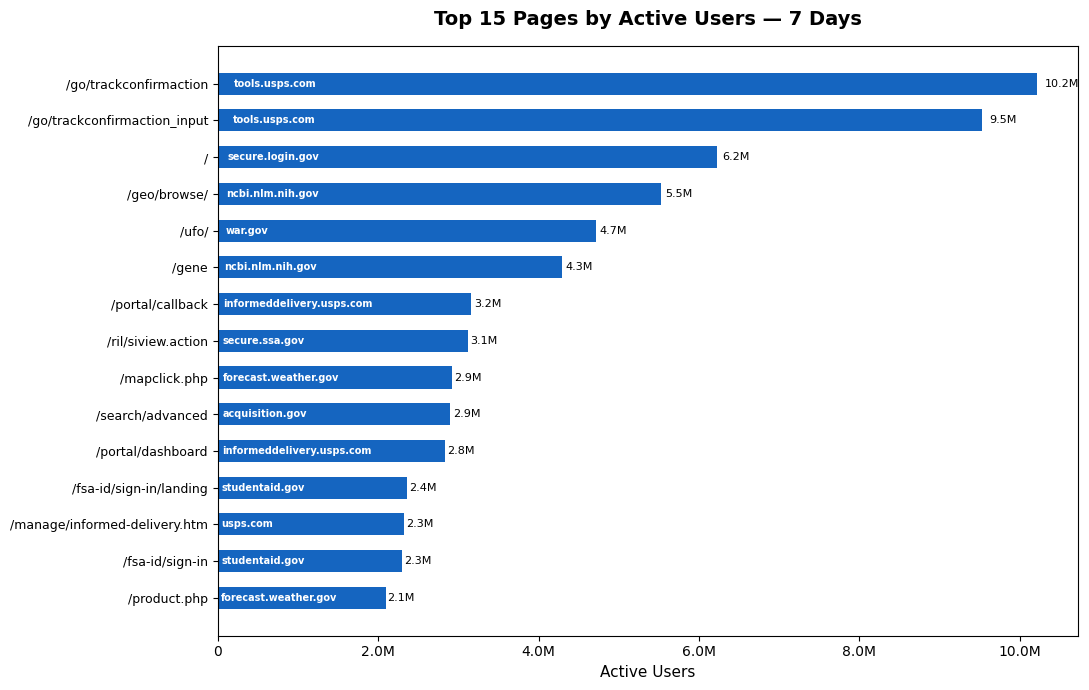

chart4_top15_pages.png saved ✓


In [ ]:
# CHART 4 — Top 15 Pages by Active Users
fig4, ax4 = plt.subplots(figsize=(11, 7))

top15        = df_merged.head(15).sort_values('active_users', ascending=True)
bars4        = ax4.barh(top15['page_short'], top15['active_users'],
                        color='#1565C0', height=0.6)

ax4.set_title('Top 15 Pages by Active Users — 7 Days',
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel('Active Users', fontsize=11)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
ax4.tick_params(axis='y', labelsize=9)

for bar in bars4:
    w = bar.get_width()
    ax4.text(w * 1.01, bar.get_y() + bar.get_height()/2,
             fmt(w), va='center', fontsize=8)

# Add domain labels on bars
for i, (_, row) in enumerate(top15.iterrows()):
    ax4.text(row['active_users'] * 0.02, i,
             str(row['domain']), va='center',
             fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_top15_pages.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart4_top15_pages.png saved ✓")
plt.close()

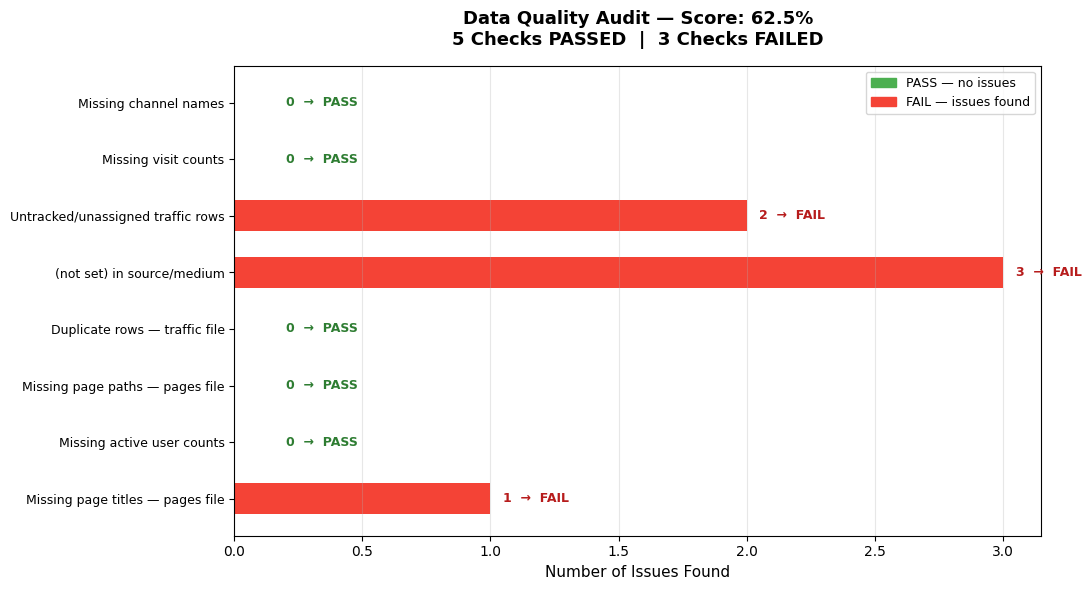

chart5_data_quality_audit.png saved ✓


In [ ]:
# CHART 5 — Data Quality Audit (RAG — Red / Amber / Green)
fig5, ax5 = plt.subplots(figsize=(11, 6))

rag   = ['#4CAF50' if s == 'PASS' else '#F44336' for s in audit_df['Status']]
bars5 = ax5.barh(audit_df['Check'], audit_df['Issues'],
                  color=rag, height=0.55)

ax5.set_title(
    f'Data Quality Audit — Score: {score}%\n'
    f'{passes} Checks PASSED  |  {fails} Checks FAILED',
    fontsize=13, fontweight='bold', pad=15)
ax5.set_xlabel('Number of Issues Found', fontsize=11)
ax5.invert_yaxis()
ax5.tick_params(axis='y', labelsize=9)
ax5.grid(axis='x', alpha=0.3)

for bar, val, status in zip(bars5, audit_df['Issues'], audit_df['Status']):
    ax5.text(max(bar.get_width() + 0.05, 0.2),
             bar.get_y() + bar.get_height()/2,
             f"{int(val)}  →  {status}",
             va='center', fontsize=9, fontweight='bold',
             color='#2E7D32' if status == 'PASS' else '#B71C1C')

ax5.legend(handles=[
    mpatches.Patch(color='#4CAF50', label='PASS — no issues'),
    mpatches.Patch(color='#F44336', label='FAIL — issues found')
], fontsize=9)

plt.tight_layout()
plt.savefig('chart5_data_quality_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("chart5_data_quality_audit.png saved ✓")
plt.close()


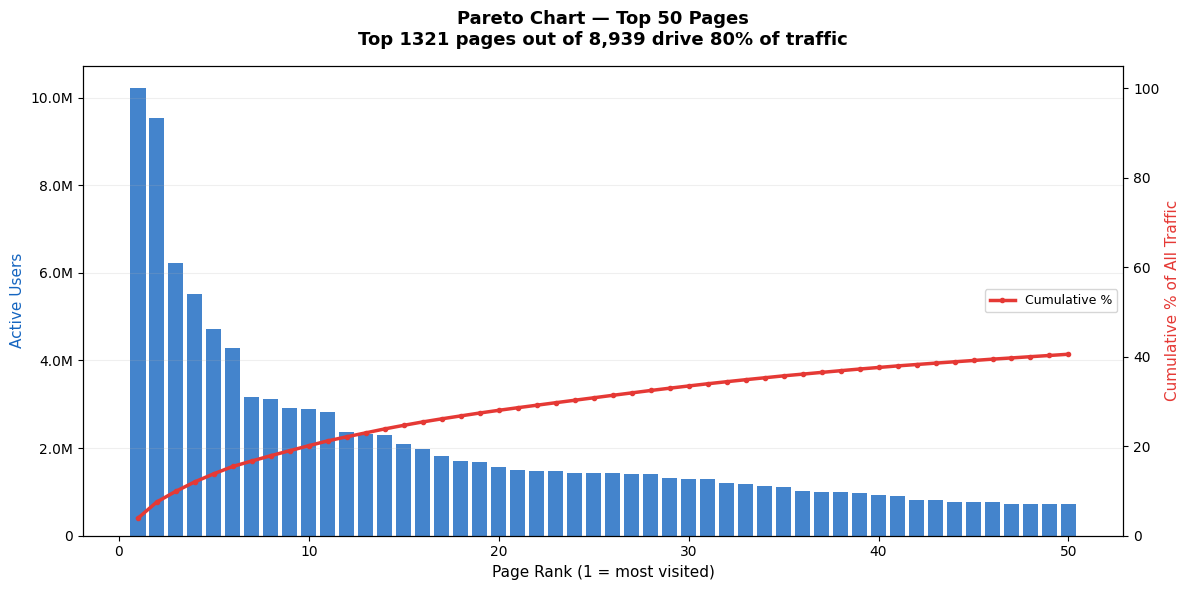

Chart 6 saved ✓


In [ ]:
#CHART 6 — Pareto Chart (which pages drive 80% of traffic)
fig6, ax6 = plt.subplots(figsize=(12, 6))
ax6b = ax6.twinx()

# Use top 50 pages only — clearly shows the drop-off
top50 = df_merged.head(50).copy()
top50['rank'] = range(1, 51)

# Recalculate cumulative % for just these 50
top50['cum_pct'] = (top50['active_users'].cumsum() /
                    df_merged['active_users'].sum() * 100).round(2)

# Bar chart — active users per page
ax6.bar(top50['rank'], top50['active_users'],
        color='#1565C0', alpha=0.8, width=0.8)

# Red line — cumulative %
ax6b.plot(top50['rank'], top50['cum_pct'],
          color='#E53935', linewidth=2.5,
          marker='o', markersize=3, label='Cumulative %')

# Find where cumulative hits 80%
hit_80 = top50[top50['cum_pct'] >= 80].head(1)
if len(hit_80) > 0:
    rank_80 = hit_80['rank'].values[0]
    ax6b.axhline(80, color='orange', linestyle='--',
                 linewidth=2, label='80% threshold')
    ax6b.axvline(rank_80, color='green', linestyle=':',
                 linewidth=2, label=f'Rank {rank_80} = 80%')
    ax6b.annotate(f'Top {rank_80} pages\n= 80% traffic',
                  xy=(rank_80, 80),
                  xytext=(rank_80 + 3, 70),
                  fontsize=10, color='green', fontweight='bold',
                  arrowprops=dict(arrowstyle='->', color='green'))

ax6.set_title(f'Pareto Chart — Top 50 Pages\n'
              f'Top {pages_for_80} pages out of {total_pages:,} drive 80% of traffic',
              fontsize=13, fontweight='bold', pad=15)
ax6.set_xlabel('Page Rank (1 = most visited)', fontsize=11)
ax6.set_ylabel('Active Users', color='#1565C0', fontsize=11)
ax6b.set_ylabel('Cumulative % of All Traffic', color='#E53935', fontsize=11)
ax6b.set_ylim(0, 105)
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt(x)))
ax6.grid(axis='y', alpha=0.2)

lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6b.legend(lines1 + lines2, labels1 + labels2,
            fontsize=9, loc='center right')

plt.tight_layout()
plt.savefig('chart6_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved ✓")
plt.close()





Insight 1 — Direct Traffic Dominates

Direct traffic is the single largest channel, accounting for the majority of all government website visits over 30 days. This suggests strong brand awareness — users are typing URLs directly rather than finding pages through search."

Insight 2 — Organic Search is Second But Far Behind

Organic Search is the second largest channel but drives significantly fewer visits than Direct. This suggests an opportunity to improve SEO so more citizens find government services through Google.

Insight 3 — Unassigned Traffic is a Data Quality Problem

A portion of traffic is labelled Unassigned - meaning the analytics tracking code failed to capture the source. This represents a data governance gap. In a regulated environment like banking, untracked data would be flagged as a compliance risk.

Insight 4 — USPS Tracking Pages Drive Massive Traffic

The top 2 most visited pages are both USPS package tracking pages, with over 10M and 9.5M active users in just 7 days. This shows that transactional, task-based pages drive far more traffic than informational pages.

Insight 5 — Pareto Rule Applies (80/20)

A small number of pages drive the majority of all traffic — consistent with the Pareto principle. This means government web teams should focus optimisation efforts on the top pages rather than trying to improve everything equally.


I analysed over 1.5 billion visits across US government websites. The most interesting finding was that Direct traffic dominated at nearly 1 billion visits, but a percentage of traffic was completely untracked — flagged as Unassigned. In a banking context that would be a serious data governance issue. I also found the Pareto principle applied just a handful of pages drove 80% of all active user traffic, which tells you exactly where to focus your optimisation effort."




In [ ]:
df_traffic.to_csv('p1_traffic_clean.csv', index=False)
print("p1_traffic_clean.csv saved ✓")

p1_traffic_clean.csv saved ✓


In [ ]:
# CSV 2 — Pages with active users + pageviews merged
df_merged.to_csv('p1_pages_clean.csv', index=False)
print("p1_pages_clean.csv saved ✓")

p1_pages_clean.csv saved ✓


In [ ]:
# CSV 3 — Audit results (for QA table in Power BI)
audit_df.to_csv('p1_audit_results.csv', index=False)
print("p1_audit_results.csv saved ✓")

p1_audit_results.csv saved ✓


In [ ]:
#CSV 4 — Domain summary
domain_agg.reset_index().rename(
    columns={'active_users': 'total_active_users'}
).to_csv('p1_domain_summary.csv', index=False)
print("p1_domain_summary.csv saved ✓")


p1_domain_summary.csv saved ✓


In [ ]:
#CSV 5 — Channel summary (clean totals for Power BI bar chart)
channel_summary = df_traffic[['channel', 'visits', 'visit_share_pct',
                               'channel_type', 'is_untracked']].copy()
channel_summary.to_csv('p1_channel_summary.csv', index=False)
print("p1_channel_summary.csv saved ✓")

p1_channel_summary.csv saved ✓


In [ ]:
# CSV 6 — Type summary (Paid vs Organic etc.)
type_summary.reset_index().rename(
    columns={'visits': 'total_visits'}
).to_csv('p1_type_summary.csv', index=False)
print("p1_type_summary.csv saved ✓")

p1_type_summary.csv saved ✓


In [ ]:
# STEP 7 — FINAL SUMMARY
print("\n" + "=" * 55)
print("ALL DONE! FILES SAVED:")
print("=" * 55)
print("""
CHARTS (6 PNG files — download and add to portfolio):
  chart1_visits_by_channel.png
  chart2_channel_share_pie.png
  chart3_traffic_by_type.png
  chart4_top15_pages.png
  chart5_data_quality_audit.png
  chart6_pareto.png

CSVs FOR POWER BI (6 files — import into Power BI):
  p1_traffic_clean.csv      → Bar chart: channel vs visits
  p1_pages_clean.csv        → Table: top pages
  p1_audit_results.csv      → Table: QA with red/green formatting
  p1_domain_summary.csv     → Bar chart: top domains
  p1_channel_summary.csv    → Pie chart: channel share
  p1_type_summary.csv       → Bar chart: paid vs organic
""")

print("POWER BI DASHBOARD — BUILD IN THIS ORDER:")
print("""
  1. Open Power BI Desktop
  2. Get Data → CSV → load p1_traffic_clean.csv
  3. Get Data → CSV → load p1_pages_clean.csv
  4. Get Data → CSV → load p1_audit_results.csv

  VISUALS TO ADD:
  ┌─────────────────────────────────────────────┐
  │  Card: Total Visits  │  Card: Total Pages   │
  │  Card: QA Score %    │  Card: Top Channel   │
  ├──────────────────────┼──────────────────────┤
  │  Bar: channel/visits │  Pie: channel share  │
  ├──────────────────────┼──────────────────────┤
  │  Table: audit_results│  Bar: top domains    │
  │  (red/green format)  │                      │
  └──────────────────────┴──────────────────────┘

  SLICERS (filters):
  → channel_type  (Paid / Organic / Direct)
  → Status        (PASS / FAIL)